### Step 1: Install Dependencies

Installs pinned Python packages required by this notebook (so results are reproducible).

- Command: `!pip install -U transformers==4.57.3
!pip install mteb==1.12.75
!pip install datasets`
- Note: This cell modifies the environment and is intended for Colab-like runtimes.


In [1]:
!pip install -U transformers==4.57.3
!pip install mteb==1.12.75
!pip install datasets

### Step 2: Notebook Cell

Runs a piece of the experiment pipeline. This cell is left as-is; the note is a placeholder for documentation.


In [2]:
from collections import Counter
import math

from datasets import load_dataset
import mteb
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer


### Step 3: Load Model and Tokenizer

Loads the tokenizer and model weights from Hugging Face, moves the model to the selected device, and enables hidden-state outputs.

- Config: `model name`, `device`
- Output: a ready-to-run model that returns `hidden_states` for layer selection.


In [3]:
DEVICE = "cuda"

# model_name = "meta-llama/Llama-3.1-8B-Instruct"
model_name = "meta-llama/Llama-3.1-8B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token_id is None:
    tokenizer.add_special_tokens({"pad_token": "[PAD]"})


model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map=DEVICE,
    torch_dtype=torch.float16,
)


model.resize_token_embeddings(len(tokenizer))

model.config.pad_token_id = tokenizer.pad_token_id

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
The new lm_head weights will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


### Step 4: Define Pooling and Layer Selection

Defines pooling functions that convert token-level representations into a single sentence embedding, plus a helper to select which transformer layers to aggregate.

- Pooling options: mean, max, EOS-based, mean excluding special tokens, and optional IDF-weighted mean
- Layer strategies: last layer, last-k average, or explicit indices


In [4]:
# ========== Poolings ==========
@torch.inference_mode()
def mean_pool(x, mask):
    mask = mask.unsqueeze(-1).to(x.dtype)
    return (x * mask).sum(1) / (mask.sum(1) + 1e-8)

@torch.inference_mode()
def max_pool(x, mask):
    mask = mask.unsqueeze(-1).to(x.dtype)
    masked = x.masked_fill(mask == 0, float("-inf"))
    return masked.max(1).values

@torch.inference_mode()
def eos_pool(x, input_ids, mask, eos_id):
    B, S, H = x.shape
    if eos_id is not None:
        has_eos = (input_ids == eos_id)
        any_eos = has_eos.any(1)
        eos_pos = torch.where(any_eos,
                              has_eos.int().cumsum(1).argmax(1),
                              torch.zeros(B, dtype=torch.long, device=input_ids.device))
    else:
        any_eos = torch.zeros(B, dtype=torch.bool, device=input_ids.device)
    last_real = mask.sum(1) - 1
    pos = torch.where(any_eos, eos_pos, last_real.clamp(min=0))
    return x[torch.arange(B, device=x.device), pos]

@torch.inference_mode()
def mean_no_special_pool(x, input_ids, mask, special_ids: set):
    spmask = ~torch.isin(input_ids, torch.tensor(list(special_ids), device=input_ids.device))
    mask2 = (mask.bool() & spmask).to(x.dtype).unsqueeze(-1)
    denom = mask2.sum(1).clamp_min_(1.0)
    return (x * mask2).sum(1) / denom

### Step 5: Notebook Cell

Runs a piece of the experiment pipeline. This cell is left as-is; the note is a placeholder for documentation.


In [5]:
@torch.inference_mode()
def select_layers(hidden_states, strategy="last", last_k=4, indices=None):
    if strategy == "last":
        return hidden_states[-1]
    if strategy == "last4":
        return torch.stack(hidden_states[-last_k:], 0).mean(0)
    if strategy == "indices":
        assert indices, "Pass indices for strategy='indices'"
        return torch.stack([hidden_states[i] for i in indices], 0).mean(0)
    raise ValueError(f"unknown layer strategy: {strategy}")

### Step 6: Define Pooling and Layer Selection

Defines pooling functions that convert token-level representations into a single sentence embedding, plus a helper to select which transformer layers to aggregate.

- Pooling options: mean, max, EOS-based, mean excluding special tokens, and optional IDF-weighted mean
- Layer strategies: last layer, last-k average, or explicit indices


In [6]:
class LLamaEncoder:
    def __init__(
        self,
        model,
        tok,
        device="cuda",
        max_len=128,
        bs=64,
        layer_strategy="last4",
        layer_indices=None,
        pooling="mean",
        l2_normalize=True,
        layer_win_tag=None,
    ):
        self.model = model
        self.tok = tok
        self.device = device
        self.max_len = max_len
        self.bs = bs
        self.layer_strategy = layer_strategy
        self.layer_indices = layer_indices
        self.pooling = pooling
        self.l2_normalize = l2_normalize

        # IDF
        self._idf = None  # dict[token_id] -> idf
        self.layer_win_tag = layer_win_tag

        torch.backends.cuda.matmul.allow_tf32 = True
        try:
            torch.set_float32_matmul_precision("high")
        except:
            pass

    # ---------- IDF/SIF ----------
    def fit_idf(self, texts, min_df=1):
        """Compute a simple IDF over a corpus (for pooling='idf_mean')."""
        df = Counter()
        N = 0
        for t in texts:
            toks = self.tok(str(t), add_special_tokens=False).input_ids
            N += 1
            for tid in set(toks):
                df[tid] += 1

        idf = {}
        for tid, d in df.items():
            if d >= min_df:
                # Simple log-based IDF
                idf[tid] = math.log((N + 1) / (d + 1)) + 1.0
        self._idf = idf

    @torch.inference_mode()
    def _idf_mean_pool(self, x, input_ids, mask):
        B, S, H = x.shape
        weights = torch.ones((B, S), device=x.device, dtype=x.dtype)
        if self._idf is not None:
            for b in range(B):
                for s in range(S):
                    tid = int(input_ids[b, s].item())
                    if tid in self._idf:
                        weights[b, s] = self._idf[tid]
        weights = weights * mask.to(x.dtype)
        denom = weights.sum(1, keepdim=True).clamp_min_(1e-8)
        return (x * weights.unsqueeze(-1)).sum(1) / denom

    @torch.inference_mode()
    def encode(self, sentences, batch_size=None, **kwargs):
        bs = batch_size or self.bs
        out_embs = []

        # Special token IDs
        special_ids = set()
        for attr in ["pad_token_id", "bos_token_id", "eos_token_id", "unk_token_id"]:
            tid = getattr(self.tok, attr, None)
            if tid is not None:
                special_ids.add(tid)

        for i in range(0, len(sentences), bs):
            batch = sentences[i : i + bs]
            enc = self.tok(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=self.max_len,
            ).to(self.device)

            out = self.model(**enc, output_hidden_states=True, return_dict=True)

            # Per-token representation [B, S, H]
            # If strategy is "last", we can directly use last_hidden_state
            if getattr(out, "last_hidden_state", None) is not None and self.layer_strategy == "last":
                token_reps = out.last_hidden_state
            else:
                hs = getattr(out, "hidden_states", None)
                if hs is None:
                    raise RuntimeError("hidden_states=None (enable output_hidden_states=True).")
                token_reps = select_layers(hs, self.layer_strategy, indices=self.layer_indices)

            # pooling
            if self.pooling == "mean":
                sent = mean_pool(token_reps.float(), enc["attention_mask"])
            elif self.pooling == "max":
                sent = max_pool(token_reps.float(), enc["attention_mask"])
            elif self.pooling == "eos":
                sent = eos_pool(
                    token_reps.float(),
                    enc["input_ids"],
                    enc["attention_mask"],
                    getattr(self.tok, "eos_token_id", None),
                )
            elif self.pooling == "mean_no_special":
                sent = mean_no_special_pool(token_reps.float(), enc["input_ids"], enc["attention_mask"], special_ids)
            elif self.pooling == "idf_mean":
                sent = self._idf_mean_pool(token_reps.float(), enc["input_ids"], enc["attention_mask"])
            else:
                raise ValueError(f"unknown pooling: {self.pooling}")

            if self.l2_normalize:
                sent = torch.nn.functional.normalize(sent, dim=-1)

            out_embs.append(sent.cpu())

        return torch.cat(out_embs, 0).numpy().astype(np.float32)


### Step 7: Sanity Check Model Outputs

Runs a tiny forward pass on a probe input to confirm the model returns `hidden_states` (and optionally `last_hidden_state`).

- Why: the encoder relies on hidden states to build sentence embeddings from specific layers.


In [7]:
# Quick sanity check that hidden_states are available
with torch.inference_mode():
    _dbg = model(
        **tokenizer("test", return_tensors="pt").to(DEVICE),
        output_hidden_states=True,
        return_dict=True
    )
n_states = len(_dbg.hidden_states)  # = n_layers + 1 (0 is embeddings)
n_layers = n_states - 1

# Define ranges for different strategies
first8 = list(range(1, min(1 + 8, n_states)))  # 1..8
mid_center = 1 + n_layers // 2
mid8 = list(range(max(1, mid_center - 4), min(n_states, mid_center + 4)))
last8 = list(range(max(1, n_states - 8), n_states))

def cfg_tag(cfg):
    t = cfg["layer_strategy"]
    if "layer_indices" in cfg and cfg["layer_indices"] is not None:
        t += f"-idx{len(cfg['layer_indices'])}"
    t += f"__{cfg['pooling']}"
    return t

def attach_meta(enc, tag, n_params):
    enc.model_name = f"LLaDA__{tag}"
    enc.model_card_data = {
        "name": enc.model_name,
        "revision": "grid-v1",
        "languages": ["eng-Latn"],
        "n_parameters": n_params,
        "memory_usage_mb": None,
    }

layer_cfgs = [
    {"layer_strategy": "last"},
    {"layer_strategy": "last4"},
    {
        "layer_strategy": "indices",
        "layer_indices": last8,
        "layer_win_tag": f"idx{last8[0]}-{last8[-1]}",
    },
    {
        "layer_strategy": "indices",
        "layer_indices": mid8,
        "layer_win_tag": f"idx{mid8[0]}-{mid8[-1]}",
    },
    {
        "layer_strategy": "indices",
        "layer_indices": first8,
        "layer_win_tag": f"idx{first8[0]}-{first8[-1]}",
    },
]

poolings = ["mean", "max", "eos", "mean_no_special", "idf_mean"]

# Build the grid
grid = []
for lc in layer_cfgs:
    for p in poolings:
        cfg = {
            "device": "cuda",
            "max_len": 128,
            "bs": 64,
            "l2_normalize": True,
            "pooling": p,
            **lc
        }
        grid.append(cfg)

n_params = int(sum(p.numel() for p in model.parameters()))
print("Total configs:", len(grid), " // Model parameters:", n_params)


Total configs: 25  // Model parameters: 8030269440


### Step 8: Run MTEB Evaluation Over the Grid

Iterates over each config, instantiates the encoder, optionally fits IDF weights, then runs MTEB on STSBenchmark (test split).

- Output: per-config `main_score` and a `rows` list for later ranking/export.


In [8]:
# We need data to compute IDF if pooling='idf_mean'.
# We'll use the STSBenchmark test set
ds = load_dataset("mteb/stsbenchmark-sts", "default")["test"]
idf_texts = [r["sentence1"] for r in ds] + [r["sentence2"] for r in ds]

def run_grid(configs):
    rows = []
    for cfg in configs:
        enc = LLamaEncoder(model, tokenizer, **cfg)  # Instantiate our encoder
        if cfg.get("pooling") == "idf_mean":
            # Fit IDF weights
            enc.fit_idf(idf_texts)

        tag = cfg_tag(cfg)
        attach_meta(enc, tag, n_params)
        out_dir = f"results_llada/{tag}"

        # Run on STSBenchmark
        res = mteb.MTEB(
            tasks=mteb.get_tasks(tasks=["STSBenchmark"]),
            eval_splits=["test"],
        ).run(
            enc,
            output_folder=out_dir,
            encode_kwargs={"batch_size": cfg.get("bs", 64)},
            overwrite_results=True,
        )

        # res = mteb.MTEB(tasks=mteb.get_tasks(tasks=["ArguAna"]), eval_splits=["test"]).run(enc, output_folder="results_llada/ArguAna_last_max", encode_kwargs={"batch_size":128}, overwrite_results=True)
        # res = mteb.MTEB(tasks=mteb.get_tasks(tasks=["Banking77Classification"]), eval_splits=["test"]).run(enc, output_folder="results_llada/Banking77_last_max", encode_kwargs={"batch_size":64}, overwrite_results=True)


        # Extract main_score
        main_score = float(res[0].scores["test"][0]["main_score"])

        if cfg["layer_strategy"] == "indices":
            layer_note = cfg.get("layer_win_tag", "indices")
        else:
            layer_note = cfg["layer_strategy"]

        print(f"{layer_note:>12} | {cfg['pooling']:<16} -> {main_score:.6f}")
        rows.append((cfg, main_score))
    return rows

rows = run_grid(grid)


README.md: 0.00B [00:00, ?B/s]

train.jsonl.gz:   0%|          | 0.00/278k [00:00<?, ?B/s]

validation.jsonl.gz:   0%|          | 0.00/86.4k [00:00<?, ?B/s]

test.jsonl.gz:   0%|          | 0.00/63.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5749 [00:00<?, ? examples/s]

...

      idx1-8 | mean_no_special  -> 0.497117


───────────────────────────────────────────────── Selected tasks  ─────────────────────────────────────────────────

STS

- STSBenchmark, s2s

      idx1-8 | idf_mean         -> 0.223292


### Step 9: Rank Results

Sorts all evaluated configurations by `main_score` (descending) and prints the top results for quick inspection.


In [9]:
# Sort from highest to lowest
rows_sorted = sorted(rows, key=lambda x: x[1], reverse=True)

print("\nTOP results (sorted by main_score):")
for cfg, score in rows_sorted[:10]:
    print(f"{score:.6f} | {cfg}")


TOP results (sorted by main_score):
0.579295 | {'device': 'cuda', 'max_len': 128, 'bs': 64, 'l2_normalize': True, 'pooling': 'idf_mean', 'layer_strategy': 'indices', 'layer_indices': [25, 26, 27, 28, 29, 30, 31, 32], 'layer_win_tag': 'idx25-32'}
0.571625 | {'device': 'cuda', 'max_len': 128, 'bs': 64, 'l2_normalize': True, 'pooling': 'idf_mean', 'layer_strategy': 'last4'}
0.533039 | {'device': 'cuda', 'max_len': 128, 'bs': 64, 'l2_normalize': True, 'pooling': 'idf_mean', 'layer_strategy': 'last'}
0.520596 | {'device': 'cuda', 'max_len': 128, 'bs': 64, 'l2_normalize': True, 'pooling': 'mean_no_special', 'layer_strategy': 'indices', 'layer_indices': [25, 26, 27, 28, 29, 30, 31, 32], 'layer_win_tag': 'idx25-32'}
0.506348 | {'device': 'cuda', 'max_len': 128, 'bs': 64, 'l2_normalize': True, 'pooling': 'mean_no_special', 'layer_strategy': 'last4'}
0.497117 | {'device': 'cuda', 'max_len': 128, 'bs': 64, 'l2_normalize': True, 'pooling': 'mean_no_special', 'layer_strategy': 'indices', 'layer_in

### Step 10: Export Results (CSV + ZIP)

Writes the full sorted leaderboard to a CSV file and zips it for easy download from notebook environments.


In [10]:
import csv
import shutil
import os
import zipfile

# Define the CSV filename and the zip filename
csv_filename = 'results_llama_instruct_sts.csv'
zip_filename = 'results_llama_instruct_sts.zip'

# Save the sorted results to a CSV file
with open(csv_filename, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Score', 'Config'])  # Write header
    for cfg, score in rows_sorted:
        writer.writerow([score, cfg])

print(f"Results saved to '{csv_filename}'")

# Create a zip archive containing the CSV file
if os.path.exists(csv_filename):
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        zipf.write(csv_filename, os.path.basename(csv_filename))
    print(f"'{csv_filename}' zipped successfully into '{zip_filename}'")
else:
    print(f"The file '{csv_filename}' was not found.")

# For downloading the file, you can use the left sidebar in Colab (folder icon)
# Navigate to the file 'results_llada_ret.zip', right-click, and select 'Download'.

Results saved to 'results_llama_instruct_sts.csv'
'results_llama_instruct_sts.csv' zipped successfully into 'results_llama_instruct_sts.zip'


### Step 11: Visualize Scores

Creates a simple horizontal bar chart of scores across configurations to quickly compare pooling/layer strategies.


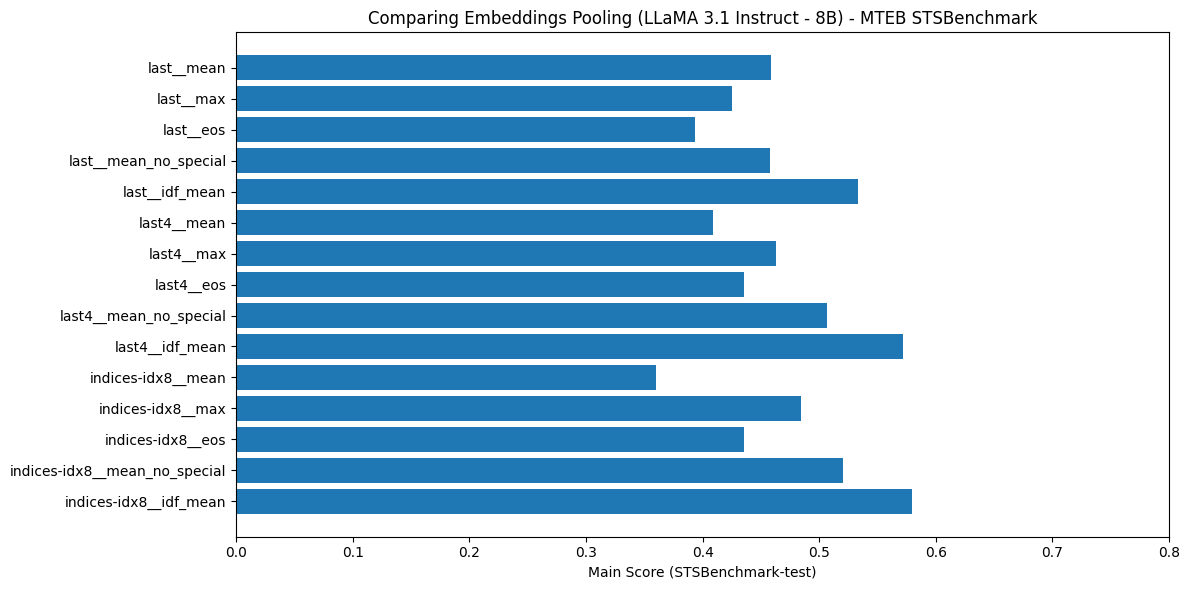

In [11]:
# Here we could generate a simple plot using matplotlib, for example
import matplotlib.pyplot as plt

# We take the configurations and scores
labels = [cfg_tag(cfg) for cfg, sc in rows]
scores = [sc for cfg, sc in rows]

plt.figure(figsize=(12, 6))
plt.barh(labels, scores)
plt.xlabel("Main Score (STSBenchmark-test)")
plt.title("Comparing Embeddings Pooling (LLaMA 3.1 Instruct - 8B) - MTEB STSBenchmark")
plt.gca().invert_yaxis()  # invert the Y-axis order
plt.xlim(0, 0.8)  # set the x-axis limit to 0.8
plt.tight_layout()

# Save the plot as SVG
plt.savefig('stsbenchmark_scores.svg', format='svg')
plt.show()

### Step 12: Package Artifacts

Creates a ZIP archive from the results folder so you can download all evaluation outputs in one file.


In [ ]:
import shutil
import os

# Set the folder to zip and the output zip filename
folder_to_zip = 'results'
zip_filename = 'results_llama.zip'

# Check if the folder exists before zipping
if os.path.exists(folder_to_zip):
    # Zip the folder
    shutil.make_archive(zip_filename.replace('.zip', ''), 'zip', folder_to_zip)
    print(f"Folder '{folder_to_zip}' zipped successfully to '{zip_filename}'")
else:
    print(f"Folder '{folder_to_zip}' was not found.")

# To download the file, you can use Colab's left sidebar (folder icon)
# Navigate to 'results_llama.zip', right-click, and select 'Download'.